# Introduction

#### This project uses the Ames Housing Dataset — a rich collection of 79 features describing home sales in Ames, Iowa between 2006 and 2010 — to build a regression model that estimates a house's sale price based on its characteristics, such as Lot Area, Garage Capacity, year built, Overall Quality and Total Basement Area. The trained model is deployed as an interactive web app where users can input property details and receive an instant price prediction.

#### The goal is to demonstrate an end-to-end data science workflow: from raw data to a deployed, user-facing application.

## Environment Setup & Data Loading data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Load data and quick check - see first five rows to understand columns
housing = pd.read_csv("Ames_Housing_Data.csv")
housing.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3. Exploratory Data Analysis (EDA)
***
### 3.1 Structural Data Diagnostics

In [3]:
#check size: rows, columns
housing.shape

(2930, 81)

In [4]:
#check data quality: which columns have missing values?
#check data type of columns
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   str    
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   str    
 6   Alley            198 non-null    str    
 7   Lot Shape        2930 non-null   str    
 8   Land Contour     2930 non-null   str    
 9   Utilities        2930 non-null   str    
 10  Lot Config       2930 non-null   str    
 11  Land Slope       2930 non-null   str    
 12  Neighborhood     2930 non-null   str    
 13  Condition 1      2930 non-null   str    
 14  Condition 2      2930 non-null   str    
 15  Bldg Type        2930 non-null   str    
 16  House Style      2930 non-null   str    
 17  Overall Qual     2930 non

In [5]:
#check total number of rows that are duplicates
housing.duplicated().sum()

np.int64(0)

In [6]:
#find the sum of missing values in a column
housing.isnull().sum().head(10)

PID                0
MS SubClass        0
MS Zoning          0
Lot Frontage     490
Lot Area           0
Street             0
Alley           2732
Lot Shape          0
Land Contour       0
Utilities          0
dtype: int64

In [7]:
#Describe: Check numbers - price range, outliers, weird zero
housing.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [8]:
housing.columns

Index(['PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

### 3.2 Target and Feature Transformations

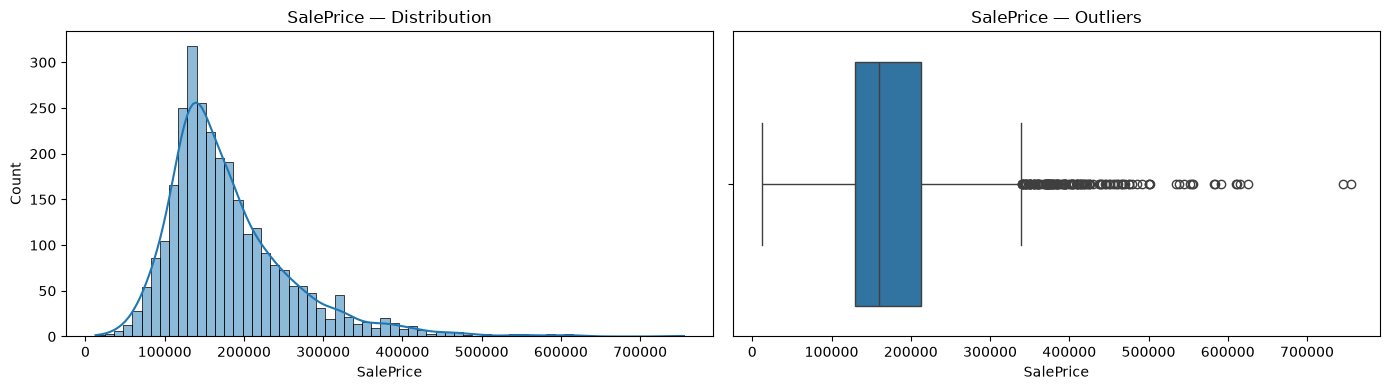

Skewness: 1.7435000757376466
Kurtosis: 5.118899951130896


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(housing['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("SalePrice — Distribution")

sns.boxplot(x=housing['SalePrice'], ax=axes[1])
axes[1].set_title("SalePrice — Outliers")

plt.tight_layout(); plt.show()

print("Skewness:", housing['SalePrice'].skew())
print("Kurtosis:", housing['SalePrice'].kurt())

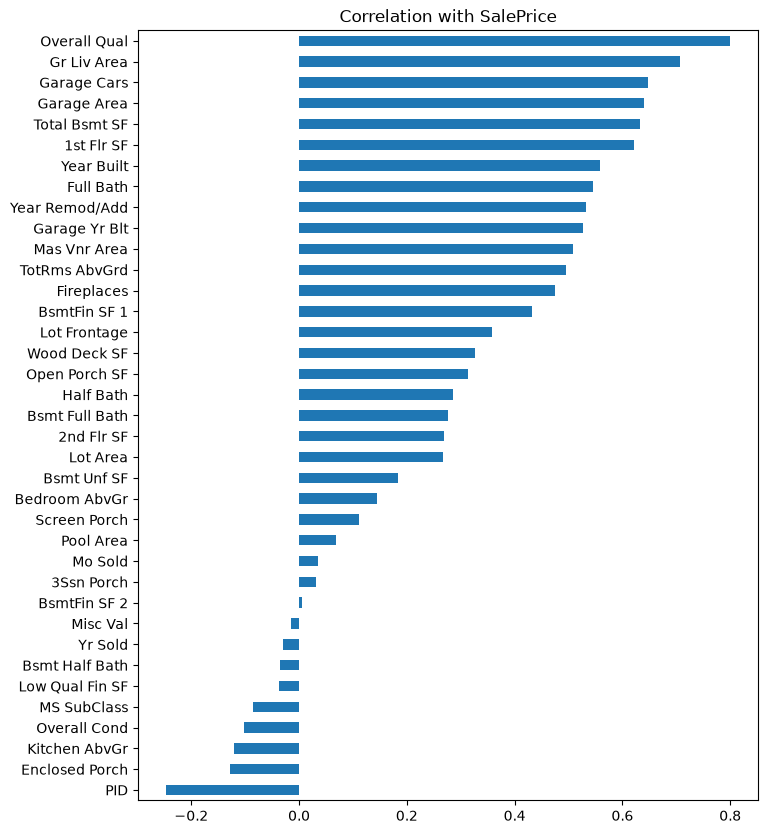

In [10]:
#correlation with target
housing.corr(numeric_only=True)['SalePrice'].drop('SalePrice')\
       .sort_values().plot(kind='barh', figsize=(8,10))
plt.title("Correlation with SalePrice"); plt.show()

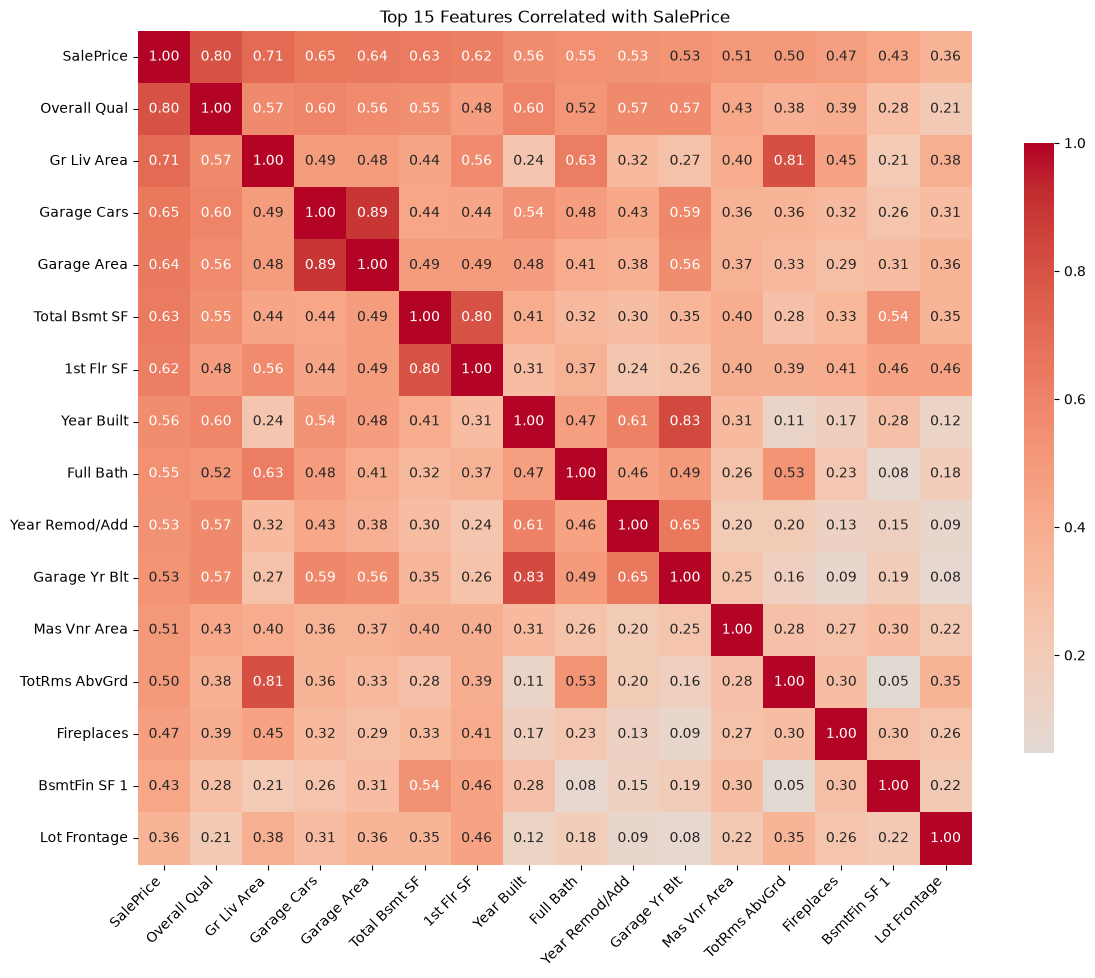

In [11]:
# Get top 15 features most correlated with SalePrice using Heatmap
top_corr = housing.corr(numeric_only=True)['SalePrice'] \
                  .abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(12, 10))
sns.heatmap(housing[top_corr].corr(),
            annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title("Top 15 Features Correlated with SalePrice")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature Selection & Data Splitting

In [12]:
#Drop low variance columns(columns with >98% same value - no info)+ leaky sales cols + terget
#low variance col have near-zero variance: removing them keeps RMSE same but cleans model
low_var = ['Street','Utilities','Condition 2','Roof Matl','Heating',
           'Pool Area', 'Misc Feature','Misc Val',
          'Low Qual Fin SF','3Ssn Porch','PID','Bsmt Half Bath',
           'Kitchen AbvGr','Garage Yr Blt','Exter Cond']

X = housing.drop(columns=low_var + ['SalePrice', 'Mo Sold','Yr Sold','Sale Type', 'Sale Condition'])
y = housing['SalePrice'].copy()
print(y)

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: SalePrice, Length: 2930, dtype: int64


### Train-Test Split

In [13]:
#splitting data into training and testing sets
#Using 80% for training and 20% for testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
#Apply log to target variable after splitting
# Why log1? SalePrice is highly right-skewed. log1p = log(1+x) normalizes it
#improves model performance
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

#Verify Transformation: values change from  ~100000 to ~11-13
print(y_train.head())

381     11.931642
834     12.128117
1898    11.530775
678     11.407576
700     11.456895
Name: SalePrice, dtype: float64


In [15]:
X_train.shape

(2344, 61)

In [16]:
X_test.shape

(586, 61)

###  Target Transformation(log1p) plot

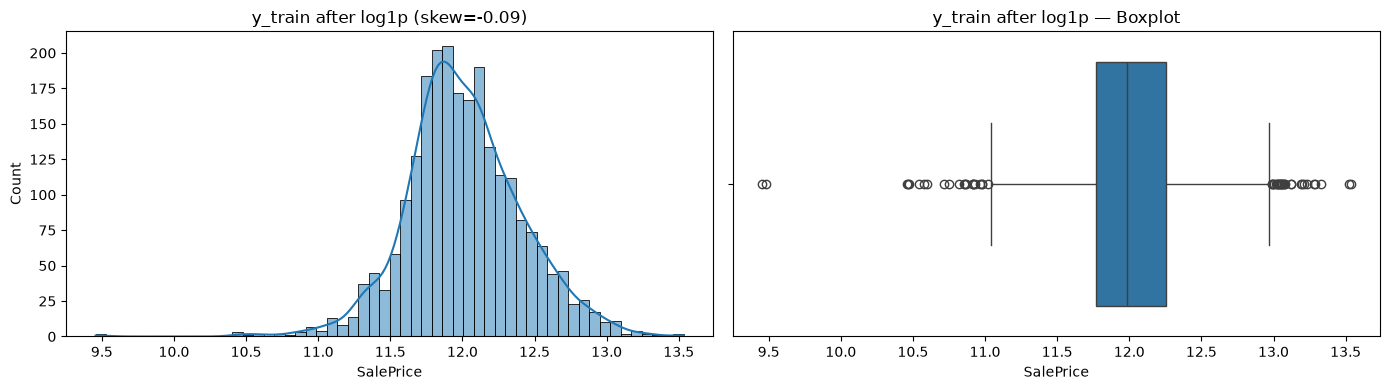

Before log skew: 1.7435000757376466
After  log skew: -0.09069864066048615


In [17]:
# 7. Verify the Log Transform Worked
# After log1p, skewness should drop from ~1.74 to ~0.1
# Histogram should look more symmetric (bell-shaped)
# Boxplot should have fewer outliers & shorter whiskers

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title(f"y_train after log1p (skew={y_train.skew():.2f})")

sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_title("y_train after log1p — Boxplot")

plt.tight_layout()
plt.show()

print("Before log skew:", housing['SalePrice'].skew())
print("After  log skew:", y_train.skew())

## Model Training & Evaluation

In [18]:
import warnings
warnings.filterwarnings('ignore')

#processes X (fit on train apply to test)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [19]:
# --- Fill structural NaNs ---
# These NaNs means "feature doesn't exist" (e.g., no basement)
none_cols = ['Alley','Bsmt Qual','Bsmt Cond','Bsmt Exposure',
             'BsmtFin Type 1','BsmtFin Type 2','Fireplace Qu',
             'Garage Type','Garage Finish','Garage Qual','Garage Cond',
             'Pool QC','Fence','Mas Vnr Type']

# Numerical zeros (no garage → area = 0)
zero_cols = ['Mas Vnr Area','Garage Area','Garage Cars',
             'BsmtFin SF 1','BsmtFin SF 2','Bsmt Unf SF',
             'Total Bsmt SF','Bsmt Full Bath']

for c in none_cols:
    if c in X_train.columns:
        X_train[c] = X_train[c].fillna("None")
        X_test[c]  = X_test[c].fillna("None")

for c in zero_cols:
    if c in X_train.columns:
        X_train[c] = X_train[c].fillna(0)
        X_test[c]  = X_test[c].fillna(0)


print(f"Numerical: {len(num_cols)} | Categorical: {len(cat_cols)}")

Numerical: 27 | Categorical: 34


In [20]:
# --- Build pipeline ---
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# --- Fit on train, transform both ---
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("X_train_proc:", X_train_proc.shape)
print("X_test_proc: ", X_test_proc.shape)

X_train_proc: (2344, 253)
X_test_proc:  (586, 253)


## Model Exploration & Predictive Validation

In [21]:
#Evaluation of original doller scale
#Model is trained on log1(SalePrice), so i convert predictions and y_test back with expm1
#to calculate RMSE in dollers and R2. lower RMSE and higher R2 score is better.
#linear regression is baseline, RandomForest capture non linear relationships.
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = np.expm1(model.predict(X_test))#convert log back to dollers
    true = np.expm1(y_test)#convert log back to dollers
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    print(f"{model.__class__.__name__:25} | RMSE: ${rmse:>10,.0f} | R²: {r2:.4f}")
    return model

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

evaluate(LinearRegression(), X_train_proc, y_train, X_test_proc, y_test)
evaluate(RandomForestRegressor(random_state=42), X_train_proc, y_train, X_test_proc, y_test)

LinearRegression          | RMSE: $    31,400 | R²: 0.8770
RandomForestRegressor     | RMSE: $    26,815 | R²: 0.9103


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [23]:
#Graident Boosting improves over Random Forest by sequentially correcting errors
#n_estimators=500: 500 trees, learning rate=0.05: small steps to avoid overfitting
#Best model so far

from sklearn.ensemble import GradientBoostingRegressor
evaluate(GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                   random_state=42),
         X_train_proc, y_train, X_test_proc, y_test)

GradientBoostingRegressor | RMSE: $    23,947 | R²: 0.9285


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [24]:
#Final comparison with advanced boosting models
#XGBoost and lightGBM are optimised
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

evaluate(XGBRegressor(n_estimators=500, learning_rate=0.05,
                      random_state=42),
         X_train_proc, y_train, X_test_proc, y_test)

evaluate(LGBMRegressor(n_estimators=500, learning_rate=0.05,
                       random_state=42),
         X_train_proc, y_train, X_test_proc, y_test)

XGBRegressor              | RMSE: $    25,311 | R²: 0.9201
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3620
[LightGBM] [Info] Number of data points in the train set: 2344, number of used features: 196
[LightGBM] [Info] Start training from score 12.011814
LGBMRegressor             | RMSE: $    24,798 | R²: 0.9233


,learning_rate,0.05
,n_estimators,500
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [25]:
# Best model so far: Gradient Boosting
#cross validation to check model stability:
# Cross-validated R²: 0.8914 (± 0.0137)
# This means the model explains ~89% of house price variation,
# and the score is stable across different data splits.

from sklearn.pipeline import Pipeline 
from sklearn.model_selection import cross_val_score

# wrap preprocessor + model in a Pipeline so the preprocessor
# is refit inside every CV fold (no leakage)
cv_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(random_state=42)),
])

# pass RAW X_train to cross_val_score
scores = cross_val_score(cv_pipe, X_train, y_train,
                         cv=5, scoring='r2')
print("CV R²:", scores.mean().round(4), "±", scores.std().round(4))

CV R²: 0.8914 ± 0.0137


## Hyperparameter Optimization & Evaluation

In [26]:
# -----------GridSearchCV--------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

grid_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(random_state=42)),
])

grid = GridSearchCV(
    grid_pipe,
    {'model__n_estimators':  [300, 500],
     'model__learning_rate': [0.05, 0.1],
     'model__max_depth':     [3, 4]},
    cv=5, scoring='r2', n_jobs=-1             # 5 fold, all cpu core
)
grid.fit(X_train, y_train)

print(grid.best_score_.round(4), grid.best_params_)

0.8983 {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 500}


### Holdout Set Diagnostics & Residual Evaluation

In [27]:
# Predict on UNSEEN test set & compare vs actual
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred = np.expm1(grid.predict(X_test))
true = np.expm1(y_test.to_numpy())

# Side-by-side: predicted vs actual (first 10)
# Residual = Actual − Predicted  (positive → model under-predicted)
print(f"{'Predicted':>12} | {'Actual':>12} | {'Residual (A-P)':>15}")
print("-" * 46)
for p, t in zip(pred[:10], true[:10]):
    print(f"${p:>11,.0f} | ${t:>11,.0f} | ${t-p:>14,.0f}")   # 👈 changed p-t → t-p

# Overall score
rmse = np.sqrt(mean_squared_error(true, pred))
r2   = r2_score(true, pred)
print(f"\nRMSE: ${rmse:,.0f}  |  R²: {r2:.4f}")

   Predicted |       Actual |  Residual (A-P)
----------------------------------------------
$    172,722 | $    161,000 | $       -11,722
$    101,119 | $    116,000 | $        14,881
$    178,818 | $    196,500 | $        17,682
$    125,775 | $    123,600 | $        -2,175
$    117,910 | $    126,000 | $         8,090
$    176,576 | $    174,190 | $        -2,386
$    167,293 | $    200,000 | $        32,707
$    150,065 | $    148,500 | $        -1,565
$     91,149 | $     88,750 | $        -2,399
$    389,591 | $    409,900 | $        20,309

RMSE: $23,835  |  R²: 0.9291


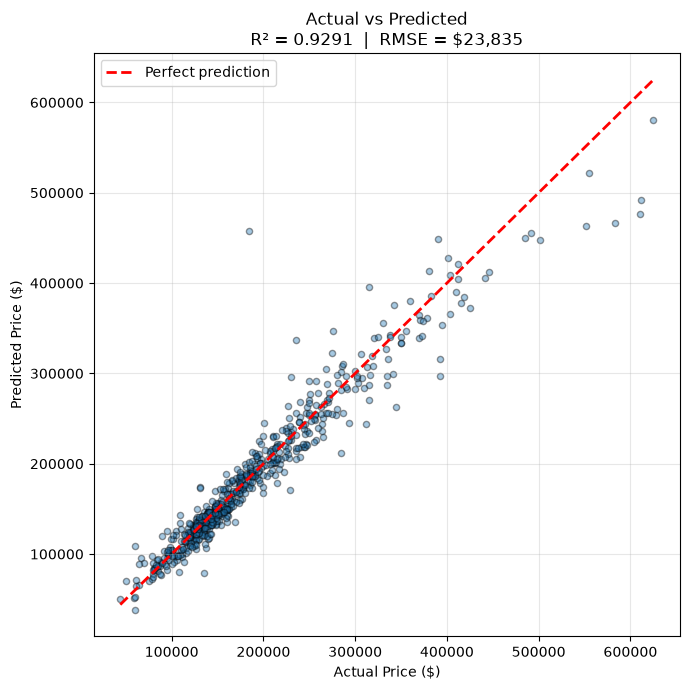

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# 1. Get predictions on test set (un-logged to dollars)
pred = np.expm1(grid.predict(X_test))
true = np.expm1(y_test.to_numpy())

r2   = r2_score(true, pred)
rmse = np.sqrt(mean_squared_error(true, pred))

# ---------- Plot 1: Actual vs Predicted ----------
plt.figure(figsize=(7, 7))
plt.scatter(true, pred, alpha=0.4, edgecolor='k', s=20)
plt.plot([true.min(), true.max()],
         [true.min(), true.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Actual vs Predicted\nR² = {r2:.4f}  |  RMSE = ${rmse:,.0f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# residual = actual vs predicted
residuals = true - pred
print("First 10 residuals (in $):")
print(np.round(residuals[:10], 2))

First 10 residuals (in $):
[-11721.96  14880.63  17681.77  -2174.62   8089.65  -2386.15  32707.18
  -1564.69  -2398.74  20309.2 ]


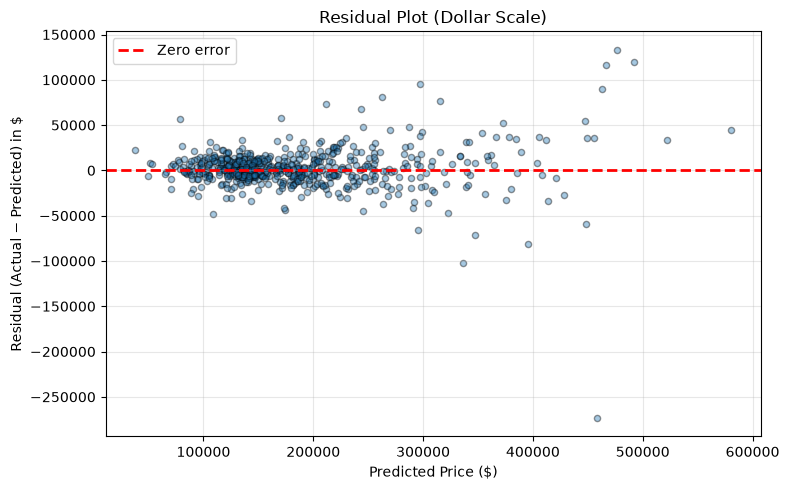

In [30]:
# ---------- Plot 2: Residuals ----------
# check model error
# if residual >0: model under-predicted
# if residual < 0: model over-predicted
# scatter predicted vs eror to see bias and variance

plt.figure(figsize=(8, 5))
plt.scatter(pred, residuals, alpha=0.4, edgecolor='k', s=20)
plt.axhline(0, color='red', linestyle='--', lw=2, label='Zero error')
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual − Predicted) in $")
plt.title("Residual Plot (Dollar Scale)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# ------Feature Importnce--------
final_model = grid.best_estimator_

# best_estimator_ is a Pipeline → use named_steps
feature_names = final_model.named_steps['prep'].get_feature_names_out()
importances   = final_model.named_steps['model'].feature_importances_ 

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

imp_df.head(20)

,feature,importance
0,num__Overall Qual,0.491386
1,num__Gr Liv Area,0.120757
2,num__Year Built,0.068381
3,num__Garage Cars,0.037474
4,num__1st Flr SF,0.033817
5,num__Total Bsmt SF,0.026721
6,num__BsmtFin SF 1,0.021876
7,num__Year Remod/Add,0.020247
8,num__Lot Area,0.018822
9,num__Garage Area,0.018095


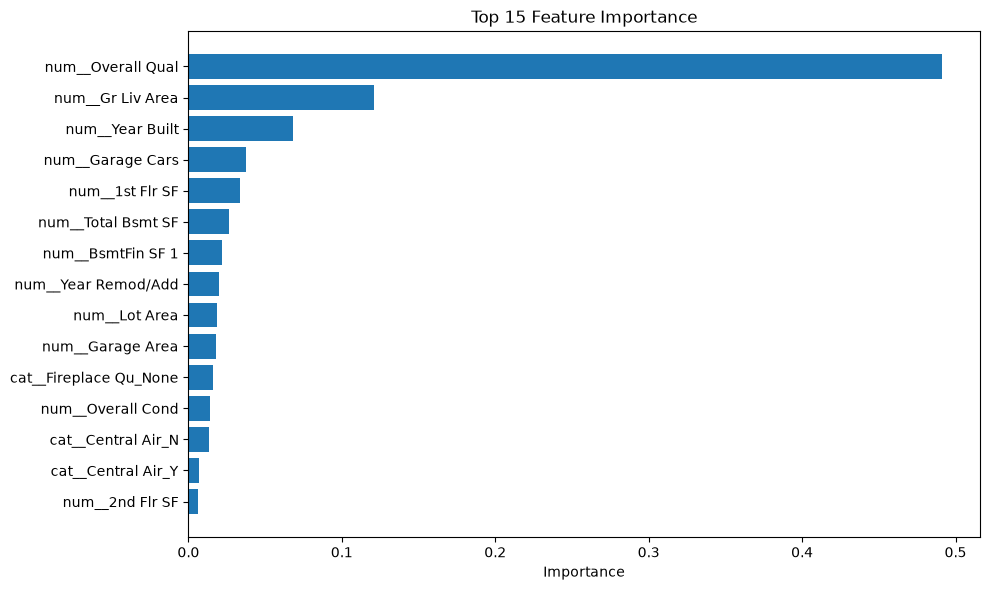

In [32]:
# -------Feature Importance Plot------
top15 = imp_df.head(15)
plt.figure(figsize=(10,6))
plt.barh(top15['feature'][::-1], top15['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

## Model Deployment

In [33]:
import joblib

In [34]:
import pathlib
desktop = pathlib.Path.home() / "Desktop" / "ames-app"
desktop.mkdir(exist_ok=True)

joblib.dump(grid.best_estimator_, desktop / 'ames_model.pkl' )
joblib.dump(preprocessor, desktop /'ames_preprocessor.pkl' )

print('DONE! 2 files saved')
print(f"Model:", grid.best_params_)

DONE! 2 files saved
Model: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 500}
